In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import sys
sys.path.append('src')

clean_signals = np.load('data/simulated_clean/signals.npy')
noisy_signals = np.load('data/simulated_noisy/signals_noisy.npy')
freq_axis     = np.load('data/simulated_clean/freq_axis.npy')

print(f"Clean  : {clean_signals.shape}")
print(f"Noisy  : {noisy_signals.shape}")
print(f"Device : {'cuda' if torch.cuda.is_available() else 'cpu'}")

Clean  : (1000, 512)
Noisy  : (1000, 512)
Device : cpu


In [2]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(noisy_signals, clean_signals, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test     = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train : {X_train.shape}")
print(f"Val   : {X_val.shape}")
print(f"Test  : {X_test.shape}")

Train : (700, 512)
Val   : (150, 512)
Test  : (150, 512)


In [3]:
device = torch.device('cpu')

X_train_t = torch.tensor(X_train).unsqueeze(1).to(device)
X_val_t   = torch.tensor(X_val).unsqueeze(1).to(device)
X_test_t  = torch.tensor(X_test).unsqueeze(1).to(device)
y_train_t = torch.tensor(y_train).unsqueeze(1).to(device)
y_val_t   = torch.tensor(y_val).unsqueeze(1).to(device)
y_test_t  = torch.tensor(y_test).unsqueeze(1).to(device)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t,   y_val_t),   batch_size=32)

print(f"Train tensor : {X_train_t.shape}")
print(f"Val tensor   : {X_val_t.shape}")
print(f"Test tensor  : {X_test_t.shape}")

Train tensor : torch.Size([700, 1, 512])
Val tensor   : torch.Size([150, 1, 512])
Test tensor  : torch.Size([150, 1, 512])


In [4]:
class THz_Autoencoder(nn.Module):
    def __init__(self):
        super(THz_Autoencoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose1d(32, 16, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose1d(16, 1,  kernel_size=4, stride=2, padding=1),
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

model = THz_Autoencoder().to(device)
print(model)
print(f"\nTotal parameters : {sum(p.numel() for p in model.parameters()):,}")

THz_Autoencoder(
  (encoder): Sequential(
    (0): Conv1d(1, 16, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (7): ReLU()
    (8): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose1d(64, 32, kernel_size=(4,), stride=(2,), padding=(1,))
    (1): ReLU()
    (2): ConvTranspose1d(32, 16, kernel_size=(4,), stride=(2,), padding=(1,))
    (3): ReLU()
    (4): ConvTranspose1d(16, 1, kernel_size=(4,), stride=(2,), padding=(1,))
  )
)

Total parameters : 19,281


In [5]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses = []
val_losses   = []
best_val     = float('inf')

for epoch in range(50):
    model.train()
    batch_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        output = model(xb)
        loss   = criterion(output, yb)
        loss.backward()
        optimizer.step()
        batch_loss += loss.item()

    train_loss = batch_loss / len(train_loader)

    model.eval()
    with torch.no_grad():
        val_out  = model(X_val_t)
        val_loss = criterion(val_out, y_val_t).item()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), 'models/autoencoder_best.pt')

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:>3}/50 | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

print(f"\nBest val loss : {best_val:.6f}")

Epoch  10/50 | Train Loss: 0.000851 | Val Loss: 0.000661
Epoch  20/50 | Train Loss: 0.000499 | Val Loss: 0.000497
Epoch  30/50 | Train Loss: 0.000466 | Val Loss: 0.000455
Epoch  40/50 | Train Loss: 0.000446 | Val Loss: 0.000424
Epoch  50/50 | Train Loss: 0.000421 | Val Loss: 0.000420

Best val loss : 0.000405


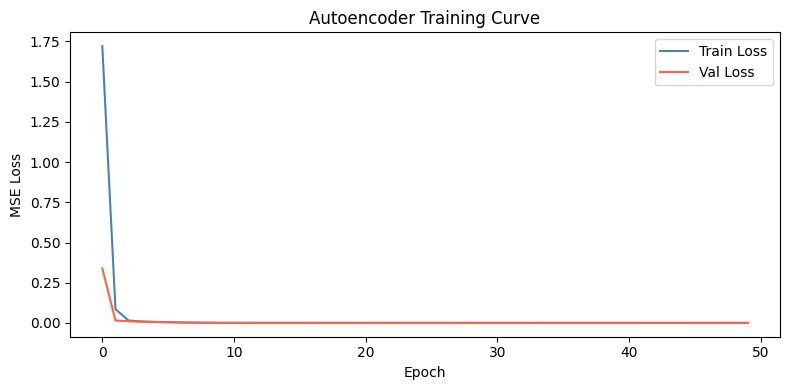

In [6]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train Loss', color='steelblue')
plt.plot(val_losses,   label='Val Loss',   color='tomato')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Autoencoder Training Curve')
plt.legend()
plt.tight_layout()
plt.savefig('results/figures/04_training_curve.png', dpi=150)
plt.show()

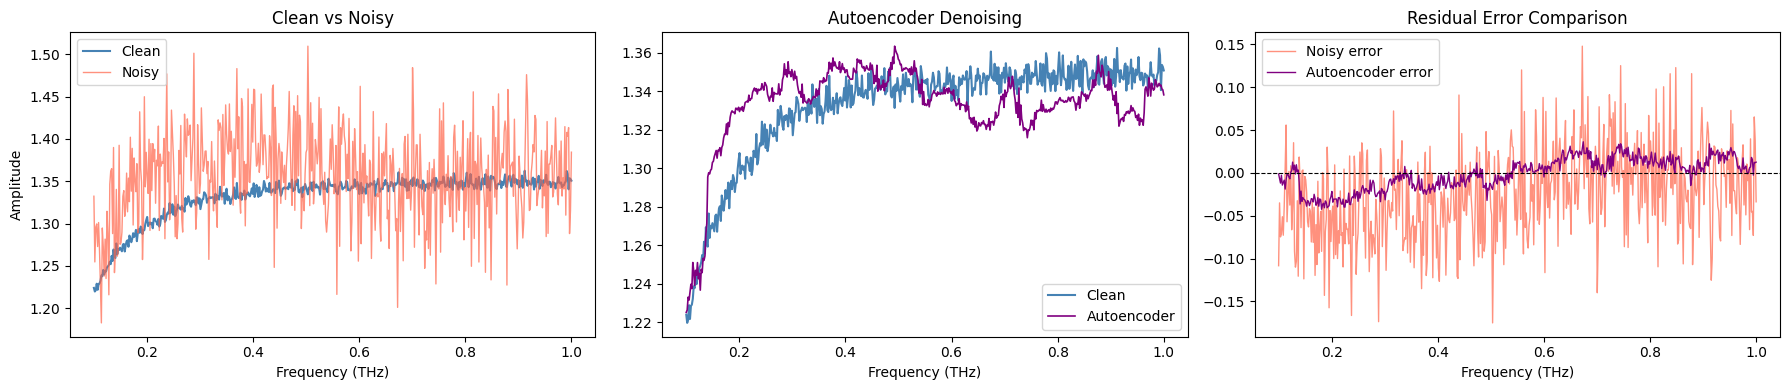

In [7]:
model.load_state_dict(torch.load('models/autoencoder_best.pt'))
model.eval()

with torch.no_grad():
    test_output = model(X_test_t).squeeze(1).numpy()

idx = 0
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(freq_axis, y_test[idx], color='steelblue', linewidth=1.5, label='Clean')
axes[0].plot(freq_axis, X_test[idx], color='tomato',    linewidth=1,   alpha=0.7, label='Noisy')
axes[0].set_title('Clean vs Noisy')
axes[0].set_xlabel('Frequency (THz)')
axes[0].set_ylabel('Amplitude')
axes[0].legend()

axes[1].plot(freq_axis, y_test[idx],      color='steelblue', linewidth=1.5, label='Clean')
axes[1].plot(freq_axis, test_output[idx], color='purple',    linewidth=1.2, label='Autoencoder')
axes[1].set_title('Autoencoder Denoising')
axes[1].set_xlabel('Frequency (THz)')
axes[1].legend()

axes[2].plot(freq_axis, y_test[idx] - X_test[idx],      color='tomato',  linewidth=1, label='Noisy error',       alpha=0.7)
axes[2].plot(freq_axis, y_test[idx] - test_output[idx], color='purple',  linewidth=1, label='Autoencoder error')
axes[2].set_title('Residual Error Comparison')
axes[2].set_xlabel('Frequency (THz)')
axes[2].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[2].legend()

plt.tight_layout()
plt.savefig('results/figures/04_autoencoder_denoising.png', dpi=150)
plt.show()

In [8]:
def compute_snr(clean, denoised):
    signal_power = np.mean(clean ** 2)
    noise_power  = np.mean((clean - denoised) ** 2)
    return 10 * np.log10(signal_power / noise_power)

def compute_rmse(clean, denoised):
    return np.sqrt(np.mean((clean - denoised) ** 2))

wavelet_all = np.load('data/processed/wavelet_denoised.npy')
savgol_all  = np.load('data/processed/savgol_denoised.npy')

snr_noisy    = np.mean([compute_snr(y_test[i],  X_test[i])        for i in range(len(y_test))])
snr_wavelet  = np.mean([compute_snr(y_test[i],  wavelet_all[i])   for i in range(len(y_test))])
snr_savgol   = np.mean([compute_snr(y_test[i],  savgol_all[i])    for i in range(len(y_test))])
snr_auto     = np.mean([compute_snr(y_test[i],  test_output[i])   for i in range(len(y_test))])

rmse_noisy   = np.mean([compute_rmse(y_test[i], X_test[i])        for i in range(len(y_test))])
rmse_wavelet = np.mean([compute_rmse(y_test[i], wavelet_all[i])   for i in range(len(y_test))])
rmse_savgol  = np.mean([compute_rmse(y_test[i], savgol_all[i])    for i in range(len(y_test))])
rmse_auto    = np.mean([compute_rmse(y_test[i], test_output[i])   for i in range(len(y_test))])

print(f"{'Method':<20} {'SNR (dB)':<15} {'RMSE':<10}")
print(f"{'-'*45}")
print(f"{'Noisy (baseline)':<20} {snr_noisy:<15.2f} {rmse_noisy:<10.4f}")
print(f"{'Wavelet':<20} {snr_wavelet:<15.2f} {rmse_wavelet:<10.4f}")
print(f"{'Savitzky-Golay':<20} {snr_savgol:<15.2f} {rmse_savgol:<10.4f}")
print(f"{'Autoencoder':<20} {snr_auto:<15.2f} {rmse_auto:<10.4f}")

Method               SNR (dB)        RMSE      
---------------------------------------------
Noisy (baseline)     26.72           0.0615    
Wavelet              32.43           0.0320    
Savitzky-Golay       30.17           0.0413    
Autoencoder          36.40           0.0202    


In [9]:
import os
os.makedirs('data/processed', exist_ok=True)
np.save('data/processed/autoencoder_denoised.npy', test_output)
print(f"Saved autoencoder outputs : {test_output.shape}")

Saved autoencoder outputs : (150, 512)
